In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import os
import pandas as pd

In [3]:
ddir = '/home/kat/Repos/SALSA/SALSA_cleanup/data/chembl/'
df = pd.read_csv(os.path.join(ddir,'chembl_valid_lte120.csv'),usecols=['Smiles'])
display(df)

,Smiles
0,CCO
1,C
2,CO
3,NCCS
4,NCCN
...,...
1476101,CC1C2CCC3C4CCC5Cc6nc7c(nc6CC5(C)C4CC(=O)C32COC...
1476102,CNC(=O)c1cc(Oc2ccc(Nc3ccc(Cl)c(C(F)(F)F)c3)cc2...
1476103,Cc1cc(C)c2c(c1)N(CCCN1CCN(c3ccccc3)CC1)C(=O)c1...
1476104,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OC(c5ccc(F)cc5F...


In [4]:
df = df.sort_values(by='Smiles')
df = df.sort_values(by='Smiles',key=lambda x: x.str.len()).reset_index(drop=True)
display(df)

,Smiles
0,C
1,CO
2,CN
3,CI
4,CF
...,...
1476101,CC(=O)NC1C(OCc2ccccc2)OC(COC(=O)CCCCCCCCCCNC(=...
1476102,C#CCC(C=CC(C)=CC(O)C1CC(OC)CC(O)(Cc2nc(C=C(C)C...
1476103,CC1CCC2(OC1)OC1CC3C4CCC5CC(OC6OC(COC(=O)Nc7ccc...
1476104,C[n+]1cn(C2OC(COP(=O)([O-])CP(=O)(O)OP(=O)(O)O...


In [6]:
%%time
from utilities.rdkit_utils import count_atoms
from pandarallel import pandarallel

pandarallel.initialize(use_memory_fs=False)

df['n_atoms'] = df.Smiles.parallel_apply(count_atoms)

INFO: Pandarallel will run on 14 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
CPU times: user 445 ms, sys: 273 ms, total: 718 ms
Wall time: 30.5 s


In [27]:
# display(df)
df_save = df
df_save.columns = map(lambda x: str(x).capitalize(), df_save.columns)
display(df_save)

fname = '/home/kat/Repos/SALSA/SALSA_cleanup/data/chembl/chembl_valid_lte120_atom_counts.csv'
df_save.to_csv(fname,index=False)

df = pd.read_csv(fname)
df

,Smiles,N_atoms
0,C,1
1,CO,2
2,CN,2
3,CI,2
4,CF,2
...,...,...
1476101,CC(=O)NC1C(OCc2ccccc2)OC(COC(=O)CCCCCCCCCCNC(=...,71
1476102,C#CCC(C=CC(C)=CC(O)C1CC(OC)CC(O)(Cc2nc(C=C(C)C...,68
1476103,CC1CCC2(OC1)OC1CC3C4CCC5CC(OC6OC(COC(=O)Nc7ccc...,71
1476104,C[n+]1cn(C2OC(COP(=O)([O-])CP(=O)(O)OP(=O)(O)O...,56


,Smiles,N_atoms
0,C,1
1,CO,2
2,CN,2
3,CI,2
4,CF,2
...,...,...
1476101,CC(=O)NC1C(OCc2ccccc2)OC(COC(=O)CCCCCCCCCCNC(=...,71
1476102,C#CCC(C=CC(C)=CC(O)C1CC(OC)CC(O)(Cc2nc(C=C(C)C...,68
1476103,CC1CCC2(OC1)OC1CC3C4CCC5CC(OC6OC(COC(=O)Nc7ccc...,71
1476104,C[n+]1cn(C2OC(COP(=O)([O-])CP(=O)(O)OP(=O)(O)O...,56


1476106
1476052


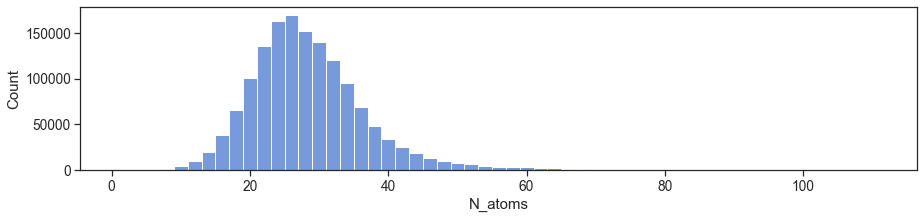

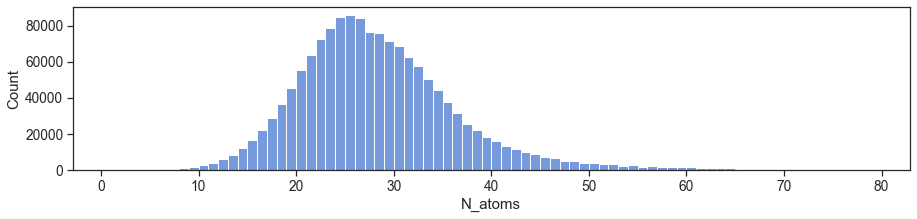

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

plt.figure(figsize=(15,3))
sns.histplot(df, x='N_atoms',binwidth=2)
print(len(df))
display()

df_trunc80 = df[df.N_atoms < 80]
fig = plt.figure(figsize=(15,3))
sns.histplot(df_trunc80, x='N_atoms',binwidth=1)
print(len(df_trunc80))
display()